In [96]:
from qiskit import *
from qiskit_aer import AerSimulator, StatevectorSimulator
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
import matplotlib.pyplot as plt

# Data generation

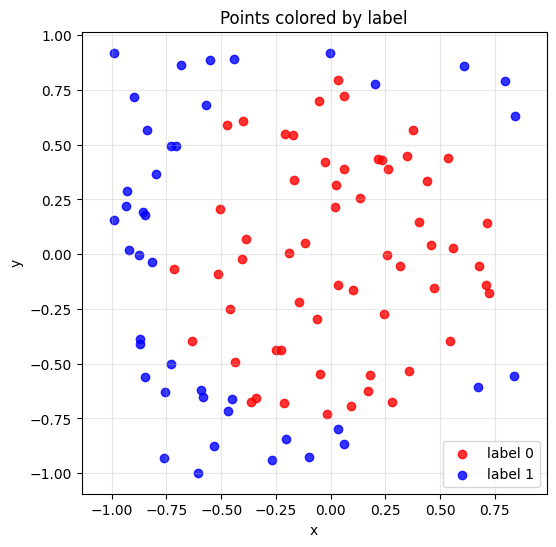

points in label 0: 58
points in label 1: 42


In [97]:
n = 100
points = np.random.rand(n, 2) * 2 - 1
labels = [0 if x**2 + y**2 < 2/np.pi else 1 for x, y in points]


import matplotlib.pyplot as plt

arr = np.array(points)
lbl = np.array(labels)

plt.figure(figsize=(6, 6))
plt.scatter(arr[lbl == 0, 0], arr[lbl == 0, 1], c="red", label="label 0", alpha=0.8)
plt.scatter(arr[lbl == 1, 0], arr[lbl == 1, 1], c="blue", label="label 1", alpha=0.8)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Points colored by label")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("points in label 0:", np.sum(lbl == 0))
print("points in label 1:", np.sum(lbl == 1))

In [98]:

test_size = 0.2
rng = np.random.default_rng(42)

indices = rng.permutation(len(arr))
split_idx = int(len(arr) * (1 - test_size))

train_idx, test_idx = indices[:split_idx], indices[split_idx:]

X_train, X_test = arr[train_idx], arr[test_idx]
y_train, y_test = lbl[train_idx], lbl[test_idx]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (80, 2) y_train: (80,)
X_test : (20, 2) y_test : (20,)


In [99]:
def U(q, theta, omega, x, qubit):
    wx = np.multiply(np.asarray(omega), np.asarray(x))  # Hadamard product
    q.rx(theta[0] + wx[0], qubit)
    q.rz(theta[1] + wx[1], qubit)

In [100]:
rc = 3

def create_circuit(x, theta, omega):
    qc = QuantumCircuit(1)
    for i in range(rc):
        U(qc, theta[i], omega[i], x, 0)
    qc.measure_all()
    qc.draw()
    return qc


In [101]:
theta = [[1,1] for _ in range(rc)]
omega = [[1,1] for _ in range(rc)]
qc =create_circuit(X_train[0], theta, omega)
qc.draw()

┌─────────────┐┌────────────┐┌─────────────┐┌────────────┐»
     q: ┤ Rx(0.16245) ├┤ Rz(1.5654) ├┤ Rx(0.16245) ├┤ Rz(1.5654) ├»
        └─────────────┘└────────────┘└─────────────┘└────────────┘»
meas: 1/══════════════════════════════════════════════════════════»
                                                                  »
«        ┌─────────────┐┌────────────┐ ░ ┌─┐
«     q: ┤ Rx(0.16245) ├┤ Rz(1.5654) ├─░─┤M├
«        └─────────────┘└────────────┘ ░ └╥┘
«meas: 1/═════════════════════════════════╩═
«                                         0

In [103]:
sim = AerSimulator()

def compute_fidelity(circuit, target_bitstring, shots=1024):
    """
    Calcule la fidélité expérimentale basée sur le shot count.
    """
    compiled_qc = transpile(circuit, sim)
    
    result = sim.run(compiled_qc, shots=shots).result()
    
    # Get counts and convert to probabilities
    counts = result.get_counts()
    
    # Convert counts to probabilities
    total_shots = sum(counts.values())
    probabilities = {bitstring: count/total_shots for bitstring, count in counts.items()}
    
    # Get fidelity for target bitstring
    fidelity = probabilities.get(target_bitstring, 0)
    
    # Return cost (1 - fidelity)
    return fidelity

# Test the cost function
print("Fidelity for |0>:", compute_fidelity(qc, "0"))
print("Fidelity for |1>:", compute_fidelity(qc, "1"))



Fidelity for |0>: 0.994140625
Fidelity for |1>: 0.0087890625
